
# CatBoost + SHAP — Quality of Life Index

Reusable training and inference notebook for `catboost_qol_dataset.csv`.

**Target:** `quality_of_life_index`

The model uses the urban indicators in the supplied dataset. `city`, `state`, and `city_id` are kept as metadata and are **not** used as model features, so the model learns from the indicator vector rather than memorizing a city's identity.

The notebook:
- loads and validates the dataset
- performs a chronological train/test split
- trains `CatBoostRegressor`
- saves the reusable `.cbm` checkpoint
- saves CatBoost's resumable training snapshot
- evaluates MAE, RMSE, and R²
- runs 5-fold cross-validation
- generates native CatBoost feature importance
- generates SHAP global and per-city explanations
- exports test predictions and SHAP values
- saves model metadata for FastAPI
- demonstrates dashboard-style inference by changing Water, Green Space, Transit, and PM2.5


In [1]:

# 1. Install dependencies if necessary

%pip install -q pandas numpy scikit-learn catboost shap matplotlib joblib


Note: you may need to restart the kernel to use updated packages.


In [2]:

# 2. Imports and configuration

from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from catboost import CatBoostRegressor
import shap

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
TARGET = "quality_of_life_index"

# Dataset path: put the CSV beside this notebook or change this manually.
DATA_PATH = Path("/kaggle/input/datasets/narutokurosaki/catboost-training-data/catboost_qol_dataset.csv")

# Reusable artifact directory.
ARTIFACT_DIR = Path("artifacts") / "catboost_qol"
CHECKPOINT_DIR = ARTIFACT_DIR / "checkpoints"
PLOTS_DIR = ARTIFACT_DIR / "plots"

for directory in [ARTIFACT_DIR, CHECKPOINT_DIR, PLOTS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Artifact directory:", ARTIFACT_DIR.resolve())


Artifact directory: /kaggle/working/artifacts/catboost_qol


In [3]:

# 3. Load and validate the dataset

if not DATA_PATH.exists():
    # Convenient fallback for the uploaded file when running this notebook here.
    fallback = Path("/mnt/data/catboost_qol_dataset.csv")
    if fallback.exists():
        DATA_PATH = fallback
    else:
        raise FileNotFoundError(
            "catboost_qol_dataset.csv not found. "
            "Place it beside the notebook or update DATA_PATH."
        )

df = pd.read_csv(DATA_PATH)

print("Dataset:", DATA_PATH.resolve())
print("Shape:", df.shape)
display(df.head())

required_columns = [
    "city_id", "city", "state", "year",
    "population", "population_density",
    "workforce_participation_rate", "economic_density_score",
    "water_coverage_pct", "sewerage_coverage_pct",
    "public_transit_score", "road_quality_score",
    "internet_access_pct", "literacy_rate",
    "healthcare_facilities_per_100k", "crime_rate_per_100k",
    "school_access_pct", "poverty_rate_pct",
    "informal_settlement_pct", "gender_workforce_gap_pct",
    "pm25_ug_m3", "pm10_ug_m3", "no2_ug_m3",
    "green_space_pct", "waste_collection_pct",
    "waste_treatment_pct", "municipal_service_score",
    "governance_score", TARGET
]

missing_columns = sorted(set(required_columns) - set(df.columns))
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

print("\nMissing values:")
display(df[required_columns].isna().sum().sort_values(ascending=False).head(10))

print("\nYears:", df["year"].min(), "to", df["year"].max())
print("Cities:", df["city"].nunique())
print("Target range:", df[TARGET].min(), "to", df[TARGET].max())


Dataset: /kaggle/input/datasets/narutokurosaki/catboost-training-data/catboost_qol_dataset.csv
Shape: (260, 29)


,city_id,city,state,year,population,population_density,workforce_participation_rate,economic_density_score,water_coverage_pct,sewerage_coverage_pct,...,gender_workforce_gap_pct,pm25_ug_m3,pm10_ug_m3,no2_ug_m3,green_space_pct,waste_collection_pct,waste_treatment_pct,municipal_service_score,governance_score,quality_of_life_index
0,IN-001,Bengaluru,Karnataka,2015,9064285,12785,38.97,70.08,81.50,62.55,...,45.29,35.36,66.39,22.32,10.80,85.75,25.12,58.64,55.85,65.62
1,IN-001,Bengaluru,Karnataka,2016,9227442,13015,40.67,73.94,80.14,60.52,...,44.89,34.00,61.88,24.82,10.96,85.16,32.95,59.73,58.63,65.86
2,IN-001,Bengaluru,Karnataka,2017,9393536,13249,39.94,76.26,83.74,63.16,...,45.04,32.36,64.25,26.21,12.38,85.08,33.00,59.49,59.76,66.08
3,IN-001,Bengaluru,Karnataka,2018,9562620,13487,39.98,75.41,84.72,63.32,...,41.94,34.15,62.96,24.18,11.39,88.26,35.85,56.91,60.46,66.30
4,IN-001,Bengaluru,Karnataka,2019,9734747,13730,41.58,79.34,85.33,64.75,...,43.95,32.41,64.85,18.65,12.52,88.60,39.38,59.15,58.98,66.50



Missing values:


city_id                         0
city                            0
state                           0
year                            0
population                      0
population_density              0
workforce_participation_rate    0
economic_density_score          0
water_coverage_pct              0
sewerage_coverage_pct           0
dtype: int64


Years: 2015 to 2024
Cities: 26
Target range: 35.09 to 67.42



## 4. Define the model features

The identity columns are deliberately excluded:

- `city_id`
- `city`
- `state`

This prevents the model from simply learning a city-specific lookup table.

`year` is retained because infrastructure, environmental conditions, and service levels can change over time.


In [4]:

FEATURES = [
    "year",
    "population",
    "population_density",
    "workforce_participation_rate",
    "economic_density_score",
    "water_coverage_pct",
    "sewerage_coverage_pct",
    "public_transit_score",
    "road_quality_score",
    "internet_access_pct",
    "literacy_rate",
    "healthcare_facilities_per_100k",
    "crime_rate_per_100k",
    "school_access_pct",
    "poverty_rate_pct",
    "informal_settlement_pct",
    "gender_workforce_gap_pct",
    "pm25_ug_m3",
    "pm10_ug_m3",
    "no2_ug_m3",
    "green_space_pct",
    "waste_collection_pct",
    "waste_treatment_pct",
    "municipal_service_score",
    "governance_score",
]

X_all = df[FEATURES].copy()
y_all = df[TARGET].copy()

print("Number of features:", len(FEATURES))
print(FEATURES)


Number of features: 25
['year', 'population', 'population_density', 'workforce_participation_rate', 'economic_density_score', 'water_coverage_pct', 'sewerage_coverage_pct', 'public_transit_score', 'road_quality_score', 'internet_access_pct', 'literacy_rate', 'healthcare_facilities_per_100k', 'crime_rate_per_100k', 'school_access_pct', 'poverty_rate_pct', 'informal_settlement_pct', 'gender_workforce_gap_pct', 'pm25_ug_m3', 'pm10_ug_m3', 'no2_ug_m3', 'green_space_pct', 'waste_collection_pct', 'waste_treatment_pct', 'municipal_service_score', 'governance_score']



## 5. Chronological train/test split

Because this dataset contains repeated city observations from 2015–2024, a random split would put observations from the same city's future and past into both train and test sets.

For a more meaningful demonstration, this notebook trains on **2015–2023** and tests on **2024**.

This answers a concrete question:

> Can the model learn from historical city indicators and estimate the next year's Quality of Life Index?

For the dashboard, the final model is then retrained on all available historical observations after evaluation.


In [5]:

TEST_YEAR = df["year"].max()
TRAIN_END_YEAR = TEST_YEAR - 1

train_mask = df["year"] < TEST_YEAR
test_mask = df["year"] == TEST_YEAR

train_df = df.loc[train_mask].copy()
test_df = df.loc[test_mask].copy()

X_train = train_df[FEATURES]
y_train = train_df[TARGET]

X_test = test_df[FEATURES]
y_test = test_df[TARGET]

print(f"Training years: {train_df.year.min()}–{train_df.year.max()}")
print(f"Test year: {TEST_YEAR}")
print(f"Train rows: {len(train_df)}")
print(f"Test rows: {len(test_df)}")
print(f"Train cities: {train_df.city.nunique()}")
print(f"Test cities: {test_df.city.nunique()}")


Training years: 2015–2023
Test year: 2024
Train rows: 234
Test rows: 26
Train cities: 26
Test cities: 26


In [6]:

# 6. Train the evaluation model

SNAPSHOT_FILE = CHECKPOINT_DIR / "qol_catboost_training_snapshot"
EVAL_MODEL_FILE = ARTIFACT_DIR / "qol_catboost_eval_model.cbm"

eval_model = CatBoostRegressor(
    loss_function="RMSE",
    eval_metric="RMSE",
    iterations=1200,
    learning_rate=0.03,
    depth=5,
    l2_leaf_reg=8.0,
    random_strength=1.0,
    random_seed=RANDOM_STATE,
    verbose=100,
    allow_writing_files=True,
    save_snapshot=True,
    snapshot_file=str(SNAPSHOT_FILE),
    snapshot_interval=1,
)

eval_model.fit(
    X_train,
    y_train,
    eval_set=(X_test, y_test),
    use_best_model=True,
)

eval_model.save_model(str(EVAL_MODEL_FILE))

print("Evaluation model saved:", EVAL_MODEL_FILE.resolve())


0:	learn: 7.3023040	test: 7.3051344	best: 7.3051344 (0)	total: 57.5ms	remaining: 1m 8s
100:	learn: 2.8585070	test: 4.5427053	best: 4.5427053 (100)	total: 223ms	remaining: 2.42s
200:	learn: 1.6055428	test: 3.7889444	best: 3.7889444 (200)	total: 388ms	remaining: 1.93s
300:	learn: 1.1488303	test: 3.5293079	best: 3.5293079 (300)	total: 556ms	remaining: 1.66s
400:	learn: 0.8423295	test: 3.3703884	best: 3.3703884 (400)	total: 722ms	remaining: 1.44s
500:	learn: 0.6801814	test: 3.2777809	best: 3.2777809 (500)	total: 886ms	remaining: 1.24s
600:	learn: 0.5594590	test: 3.2080408	best: 3.2080408 (600)	total: 1.06s	remaining: 1.06s
700:	learn: 0.4772938	test: 3.1515765	best: 3.1515765 (700)	total: 1.22s	remaining: 871ms
800:	learn: 0.3911683	test: 3.1239895	best: 3.1234022 (793)	total: 1.39s	remaining: 692ms
900:	learn: 0.3282281	test: 3.1051198	best: 3.1050032 (899)	total: 1.55s	remaining: 515ms
1000:	learn: 0.2735079	test: 3.0916674	best: 3.0916674 (1000)	total: 1.71s	remaining: 340ms
1100:	learn

In [7]:
# 7. Evaluate on the 2024 holdout

test_pred = eval_model.predict(X_test)

metrics = {
    "model": "CatBoostRegressor",
    "target": TARGET,
    "train_years": [int(train_df.year.min()), int(train_df.year.max())],
    "test_year": int(TEST_YEAR),
    "n_observations": int(len(df)),
    "train_size": int(len(train_df)),
    "test_size": int(len(test_df)),
    "MAE": float(mean_absolute_error(y_test, test_pred)),
    "RMSE": float(np.sqrt(mean_squared_error(y_test, test_pred))),
    "R2": float(r2_score(y_test, test_pred)),
    "best_iteration": int(eval_model.get_best_iteration()),
}

print(json.dumps(metrics, indent=2))

with open(ARTIFACT_DIR / "evaluation_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

{
  "model": "CatBoostRegressor",
  "target": "quality_of_life_index",
  "train_years": [
    2015,
    2023
  ],
  "test_year": 2024,
  "n_observations": 260,
  "train_size": 234,
  "test_size": 26,
  "MAE": 1.9445421790807924,
  "RMSE": 3.0691897579487906,
  "R2": 0.8223008636770011,
  "best_iteration": 1193
}


In [8]:

# 8. Save test predictions

predictions = test_df[["city_id", "city", "state", "year", TARGET]].copy()
predictions["predicted_quality_of_life_index"] = test_pred
predictions["absolute_error"] = (
    predictions[TARGET] - predictions["predicted_quality_of_life_index"]
).abs()

predictions.to_csv(
    ARTIFACT_DIR / "test_predictions_2024.csv",
    index=False
)

display(predictions.sort_values("absolute_error", ascending=False))


,city_id,city,state,year,quality_of_life_index,predicted_quality_of_life_index,absolute_error
259,IN-026,Srinagar,Jammu & Kashmir,2024,36.60,46.895138,10.295138
129,IN-013,Raipur,Chhattisgarh,2024,59.19,52.932429,6.257571
159,IN-016,Jodhpur,Rajasthan,2024,58.05,52.517657,5.532343
239,IN-024,Ranchi,Jharkhand,2024,43.38,48.408971,5.028971
249,IN-025,Guwahati,Assam,2024,40.12,44.726537,4.606537
29,IN-003,Ahmedabad,Gujarat,2024,65.59,63.556392,2.033608
9,IN-001,Bengaluru,Karnataka,2024,67.42,65.987797,1.432203
19,IN-002,Pune,Maharashtra,2024,66.99,65.565390,1.424610
219,IN-022,Chandigarh,Chandigarh,2024,54.74,56.163005,1.423005
79,IN-008,Indore,Madhya Pradesh,2024,62.13,60.747846,1.382154


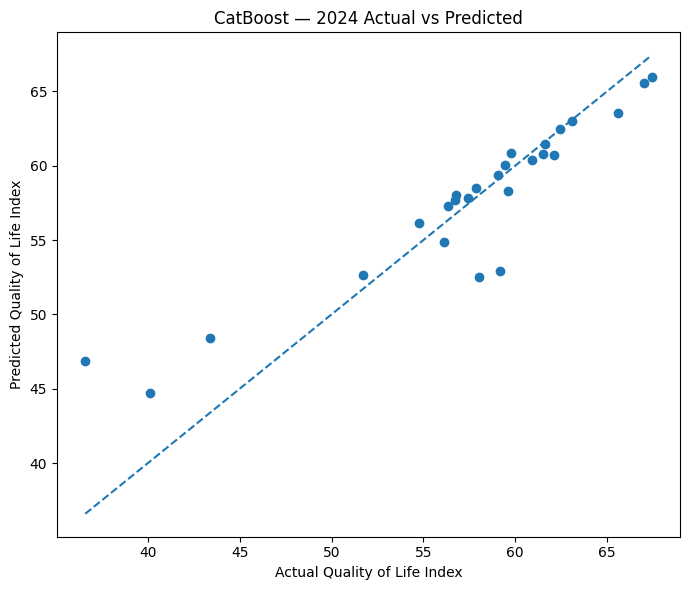

In [9]:

# 9. Actual vs predicted plot

plt.figure(figsize=(7, 6))
plt.scatter(y_test, test_pred)

low = min(float(y_test.min()), float(test_pred.min()))
high = max(float(y_test.max()), float(test_pred.max()))

plt.plot([low, high], [low, high], linestyle="--")
plt.xlabel("Actual Quality of Life Index")
plt.ylabel("Predicted Quality of Life Index")
plt.title("CatBoost — 2024 Actual vs Predicted")
plt.tight_layout()

plt.savefig(
    PLOTS_DIR / "actual_vs_predicted_2024.png",
    dpi=180,
    bbox_inches="tight"
)

plt.show()



## 10. Cross-validation

Cross-validation is included as a second performance estimate. Since the data are longitudinal, this is **not** a replacement for the chronological 2024 holdout; it is a supplementary stability check.


In [10]:

cv_model = CatBoostRegressor(
    loss_function="RMSE",
    iterations=800,
    learning_rate=0.03,
    depth=5,
    l2_leaf_reg=8.0,
    random_strength=1.0,
    random_seed=RANDOM_STATE,
    verbose=False,
)

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

cv_scores = cross_validate(
    cv_model,
    X_all,
    y_all,
    cv=kf,
    scoring={
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error",
        "r2": "r2",
    },
    return_train_score=False,
)

cv_results = {
    "MAE_mean": float(-cv_scores["test_mae"].mean()),
    "MAE_std": float(cv_scores["test_mae"].std()),
    "RMSE_mean": float(-cv_scores["test_rmse"].mean()),
    "RMSE_std": float(cv_scores["test_rmse"].std()),
    "R2_mean": float(cv_scores["test_r2"].mean()),
    "R2_std": float(cv_scores["test_r2"].std()),
}

print(json.dumps(cv_results, indent=2))

with open(ARTIFACT_DIR / "cross_validation_metrics.json", "w") as f:
    json.dump(cv_results, f, indent=2)


{
  "MAE_mean": 1.427867243711712,
  "MAE_std": 0.22342112386953644,
  "RMSE_mean": 2.0978497254389277,
  "RMSE_std": 0.3975459390343112,
  "R2_mean": 0.9177462899635014,
  "R2_std": 0.02511470043521037
}



## 11. Final reusable model

After evaluating the model, train a final model on **all available city-year observations**.

This is the model intended for your FastAPI/dashboard inference.

The evaluation model remains available separately, so you can report honest holdout metrics while using the final model for inference.


In [11]:

FINAL_MODEL_FILE = ARTIFACT_DIR / "qol_catboost_model.cbm"
FINAL_SNAPSHOT_FILE = CHECKPOINT_DIR / "qol_catboost_final_snapshot"

final_model = CatBoostRegressor(
    loss_function="RMSE",
    eval_metric="RMSE",
    iterations=1200,
    learning_rate=0.03,
    depth=5,
    l2_leaf_reg=8.0,
    random_strength=1.0,
    random_seed=RANDOM_STATE,
    verbose=100,
    allow_writing_files=True,
    save_snapshot=True,
    snapshot_file=str(FINAL_SNAPSHOT_FILE),
    snapshot_interval=1,
)

final_model.fit(
    X_all,
    y_all,
)

final_model.save_model(str(FINAL_MODEL_FILE))

print("Reusable model saved:", FINAL_MODEL_FILE.resolve())


0:	learn: 7.2963882	total: 2.72ms	remaining: 3.26s
100:	learn: 2.8405045	total: 190ms	remaining: 2.07s
200:	learn: 1.6991146	total: 369ms	remaining: 1.84s
300:	learn: 1.2058068	total: 543ms	remaining: 1.62s
400:	learn: 0.9112629	total: 722ms	remaining: 1.44s
500:	learn: 0.7073644	total: 902ms	remaining: 1.26s
600:	learn: 0.5767137	total: 1.09s	remaining: 1.09s
700:	learn: 0.4940412	total: 1.27s	remaining: 906ms
800:	learn: 0.4242915	total: 1.45s	remaining: 723ms
900:	learn: 0.3637798	total: 1.63s	remaining: 541ms
1000:	learn: 0.3064567	total: 1.81s	remaining: 360ms
1100:	learn: 0.2651567	total: 2s	remaining: 180ms
1199:	learn: 0.2272270	total: 2.18s	remaining: 0us
Reusable model saved: /kaggle/working/artifacts/catboost_qol/qol_catboost_model.cbm


,feature,importance
10,literacy_rate,17.086939
2,population_density,13.628431
15,informal_settlement_pct,10.596498
4,economic_density_score,9.668328
1,population,6.079693
17,pm25_ug_m3,5.258568
18,pm10_ug_m3,5.111790
11,healthcare_facilities_per_100k,4.386565
14,poverty_rate_pct,4.252129
5,water_coverage_pct,3.907236


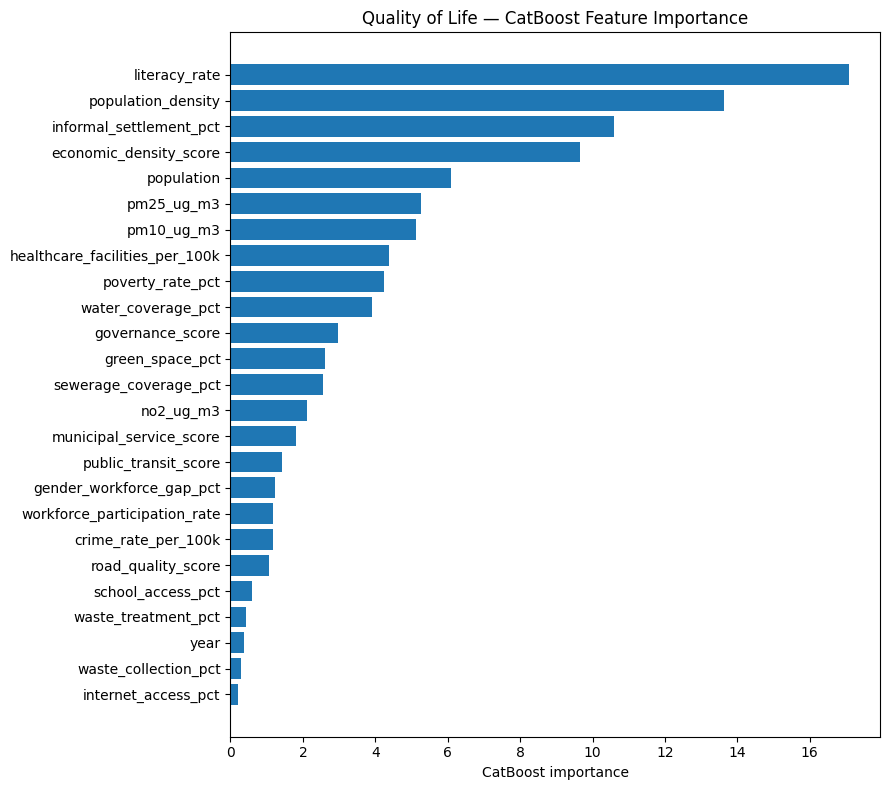

In [12]:

# 12. Native CatBoost feature importance

feature_importance = pd.DataFrame({
    "feature": FEATURES,
    "importance": final_model.get_feature_importance()
}).sort_values("importance", ascending=False)

display(feature_importance)

feature_importance.to_csv(
    ARTIFACT_DIR / "catboost_feature_importance.csv",
    index=False
)

plt.figure(figsize=(9, 8))
plt.barh(
    feature_importance["feature"].iloc[::-1],
    feature_importance["importance"].iloc[::-1]
)
plt.xlabel("CatBoost importance")
plt.title("Quality of Life — CatBoost Feature Importance")
plt.tight_layout()

plt.savefig(
    PLOTS_DIR / "catboost_feature_importance.png",
    dpi=180,
    bbox_inches="tight"
)

plt.show()



## 13. SHAP TreeExplainer

SHAP values explain how each feature moves an individual model prediction relative to the model's expected/base prediction.

They are **model attributions, not causal effects**.


In [13]:
explainer = shap.TreeExplainer(final_model)

# Compute SHAP values on the complete dataset
# for stable global analysis.
shap_all = explainer(X_all)

shap_values_df = pd.DataFrame(
    shap_all.values,
    columns=FEATURES,
    index=df.index
)

# Add metadata columns only if they are not already SHAP features
metadata = {
    "city_id": df["city_id"].values,
    "city": df["city"].values,
    "state": df["state"].values,
}

for col, values in metadata.items():
    if col not in shap_values_df.columns:
        shap_values_df.insert(0, col, values)

shap_values_df.to_csv(
    ARTIFACT_DIR / "shap_values_all.csv",
    index=False
)

print("Saved SHAP values.")
display(shap_values_df.head())

Saved SHAP values.


,state,city,city_id,year,population,population_density,workforce_participation_rate,economic_density_score,water_coverage_pct,sewerage_coverage_pct,...,informal_settlement_pct,gender_workforce_gap_pct,pm25_ug_m3,pm10_ug_m3,no2_ug_m3,green_space_pct,waste_collection_pct,waste_treatment_pct,municipal_service_score,governance_score
0,Karnataka,Bengaluru,IN-001,0.059400,0.981081,0.882938,0.092287,1.449502,0.287514,0.234204,...,0.817155,0.125502,0.582150,0.367997,0.139215,0.251138,0.111778,0.161583,0.161503,0.475983
1,Karnataka,Bengaluru,IN-001,0.019890,0.965386,0.632598,0.215406,1.755667,0.254597,0.090249,...,0.837049,0.183599,0.640577,0.386206,0.101745,0.251700,0.091302,0.042801,0.171260,0.388728
2,Karnataka,Bengaluru,IN-001,-0.010588,0.970866,0.466910,0.199261,1.867484,0.239600,0.200925,...,0.930009,0.095535,0.694977,0.353290,0.018757,0.257427,0.073157,0.044491,0.151020,0.416116
3,Karnataka,Bengaluru,IN-001,-0.003291,1.026966,0.392004,0.215876,1.735054,0.267881,0.236375,...,0.934544,0.426088,0.693309,0.350794,0.147144,0.206613,-0.029357,-0.066098,0.160090,0.393366
4,Karnataka,Bengaluru,IN-001,-0.003895,1.082386,0.372443,0.271159,1.914316,0.285446,0.235430,...,0.938205,0.334815,0.735992,0.326945,0.141273,0.170635,-0.030892,-0.046763,0.155351,0.437137


,feature,mean_abs_shap
10,literacy_rate,1.036577
4,economic_density_score,1.017271
2,population_density,0.807492
1,population,0.688630
15,informal_settlement_pct,0.625180
24,governance_score,0.428564
11,healthcare_facilities_per_100k,0.409572
5,water_coverage_pct,0.384691
17,pm25_ug_m3,0.331219
6,sewerage_coverage_pct,0.317345


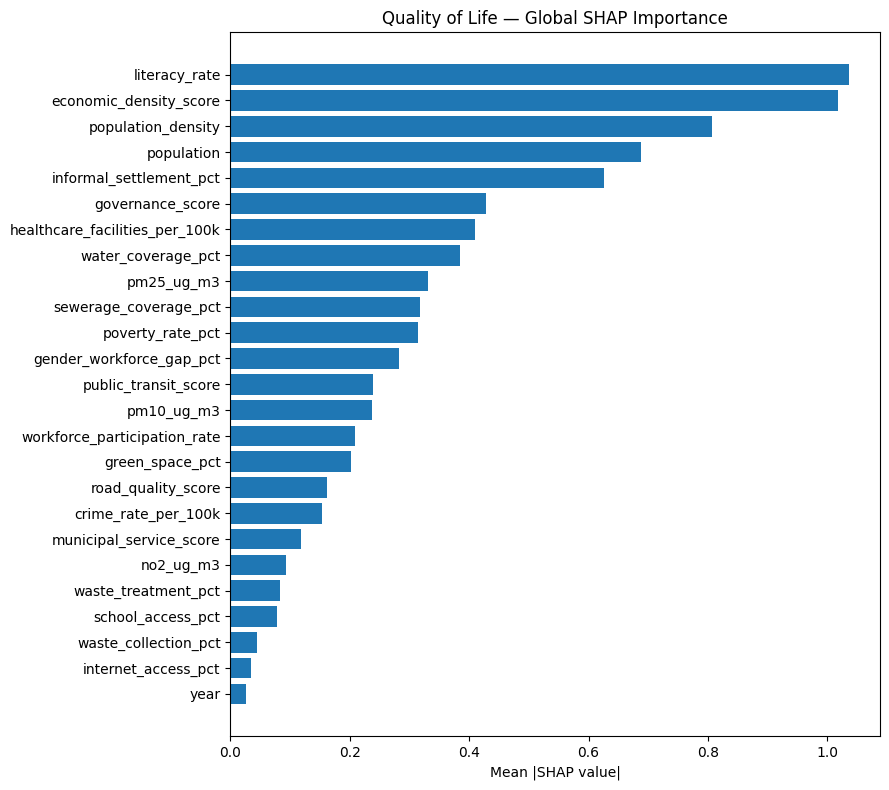

In [14]:

# 14. Global SHAP importance

global_shap = pd.DataFrame({
    "feature": FEATURES,
    "mean_abs_shap": np.abs(shap_all.values).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False)

display(global_shap)

global_shap.to_csv(
    ARTIFACT_DIR / "shap_global_importance.csv",
    index=False
)

plt.figure(figsize=(9, 8))
plt.barh(
    global_shap["feature"].iloc[::-1],
    global_shap["mean_abs_shap"].iloc[::-1]
)
plt.xlabel("Mean |SHAP value|")
plt.title("Quality of Life — Global SHAP Importance")
plt.tight_layout()

plt.savefig(
    PLOTS_DIR / "shap_global_importance.png",
    dpi=180,
    bbox_inches="tight"
)

plt.show()


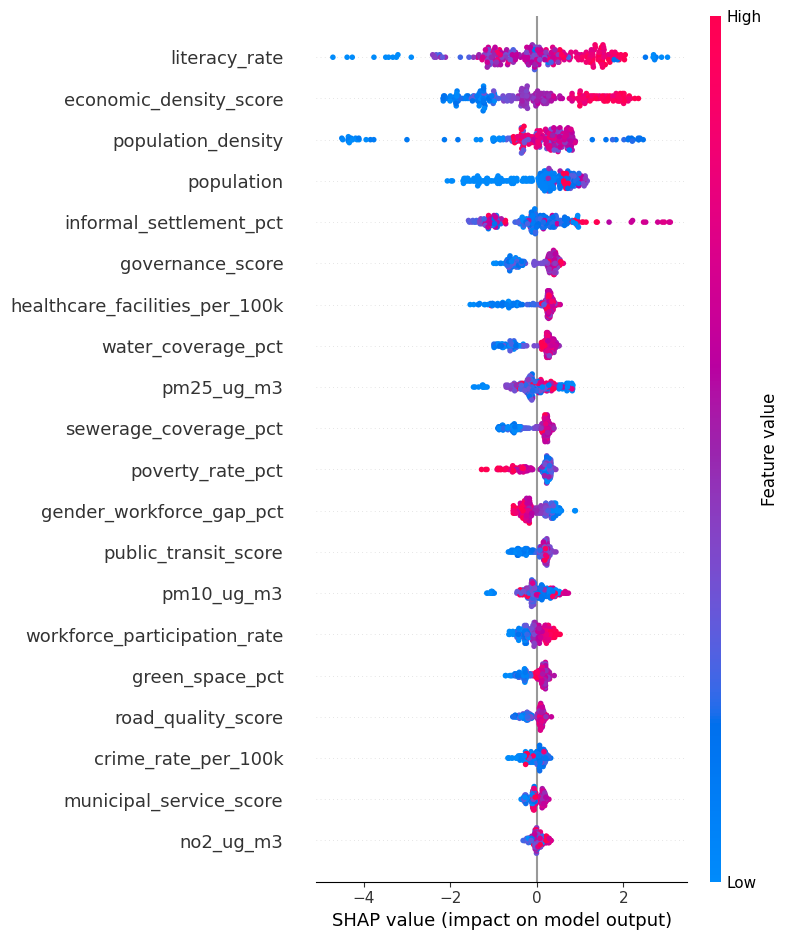

In [15]:

# 15. SHAP summary plot

plt.figure()
shap.summary_plot(
    shap_all.values,
    X_all,
    feature_names=FEATURES,
    show=False
)
plt.tight_layout()

plt.savefig(
    PLOTS_DIR / "shap_summary_beeswarm.png",
    dpi=180,
    bbox_inches="tight"
)

plt.show()



## 16. City-level SHAP explanation

Set `CITY_NAME` and `YEAR_TO_EXPLAIN` to generate the exact attribution data used by the dashboard.

The exported CSV can also be consumed directly by your FastAPI service.


In [16]:

CITY_NAME = "Bengaluru"
YEAR_TO_EXPLAIN = int(df["year"].max())

matches = df[
    (df["city"] == CITY_NAME) &
    (df["year"] == YEAR_TO_EXPLAIN)
]

if len(matches) != 1:
    raise ValueError(
        f"Expected one row for {CITY_NAME} / {YEAR_TO_EXPLAIN}, found {len(matches)}"
    )

row_index = matches.index[0]
row_X = df.loc[[row_index], FEATURES]

city_shap = explainer(row_X)

city_prediction = float(final_model.predict(row_X)[0])
city_base = float(np.asarray(city_shap.base_values).reshape(-1)[0])

city_explanation = pd.DataFrame({
    "feature": FEATURES,
    "raw_value": row_X.iloc[0].values,
    "shap_value": city_shap.values[0],
})

city_explanation["absolute_shap"] = city_explanation["shap_value"].abs()
city_explanation["direction"] = np.where(
    city_explanation["shap_value"] >= 0,
    "positive",
    "negative"
)

city_explanation = city_explanation.sort_values(
    "absolute_shap",
    ascending=False
)

print(f"City: {CITY_NAME}")
print(f"Year: {YEAR_TO_EXPLAIN}")
print(f"Model prediction: {city_prediction:.2f}")
print(f"SHAP base value: {city_base:.2f}")

display(city_explanation.head(15))

safe_city = CITY_NAME.lower().replace(" ", "_")

city_explanation.to_csv(
    ARTIFACT_DIR / f"shap_{safe_city}_{YEAR_TO_EXPLAIN}.csv",
    index=False
)


City: Bengaluru
Year: 2024
Model prediction: 67.24
SHAP base value: 56.42


,feature,raw_value,shap_value,absolute_shap,direction
10,literacy_rate,93.24,1.941267,1.941267,positive
4,economic_density_score,83.51,1.859697,1.859697,positive
1,population,10642988.00,1.026974,1.026974,positive
15,informal_settlement_pct,8.04,0.899973,0.899973,positive
16,gender_workforce_gap_pct,38.01,0.891761,0.891761,positive
17,pm25_ug_m3,31.07,0.707345,0.707345,positive
3,workforce_participation_rate,43.99,0.509545,0.509545,positive
24,governance_score,69.01,0.388362,0.388362,positive
18,pm10_ug_m3,58.46,0.363923,0.363923,positive
2,population_density,15011.00,0.329860,0.329860,positive


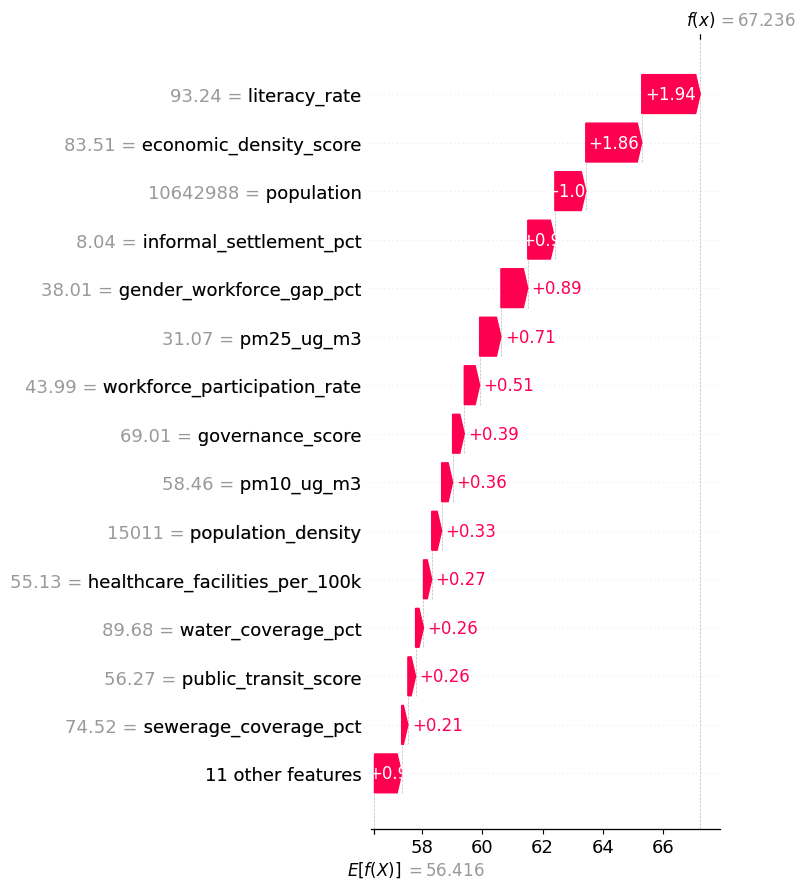

In [17]:

# 17. SHAP waterfall plot for the selected city

shap.plots.waterfall(
    city_shap[0],
    max_display=15,
    show=False
)

plt.tight_layout()
plt.savefig(
    PLOTS_DIR / f"shap_{safe_city}_{YEAR_TO_EXPLAIN}_waterfall.png",
    dpi=180,
    bbox_inches="tight"
)
plt.show()



## 18. Dashboard-style inference

This section demonstrates the exact pattern your frontend can use.

The four interactive controls correspond to:

- `water_coverage_pct`
- `green_space_pct`
- `public_transit_score`
- `pm25_ug_m3`

The other indicators are taken from a selected city/year baseline.

For a production dashboard, FastAPI should receive the modified feature vector and run the saved `.cbm` model.


In [18]:

# Select a baseline city/year.
BASELINE_CITY = "Bengaluru"
BASELINE_YEAR = int(df["year"].max())

baseline = df[
    (df["city"] == BASELINE_CITY) &
    (df["year"] == BASELINE_YEAR)
]

if len(baseline) != 1:
    raise ValueError("Baseline city/year did not resolve to exactly one row.")

dashboard_input = baseline[FEATURES].copy()

# Simulated slider values.
dashboard_input.loc[:, "water_coverage_pct"] = 88.0
dashboard_input.loc[:, "green_space_pct"] = 32.0
dashboard_input.loc[:, "public_transit_score"] = 75.0
dashboard_input.loc[:, "pm25_ug_m3"] = 3.8

dashboard_prediction = float(final_model.predict(dashboard_input)[0])
dashboard_shap = explainer(dashboard_input)

dashboard_explanation = pd.DataFrame({
    "feature": FEATURES,
    "raw_value": dashboard_input.iloc[0].values,
    "shap_value": dashboard_shap.values[0],
})

dashboard_explanation["absolute_shap"] = dashboard_explanation["shap_value"].abs()
dashboard_explanation["direction"] = np.where(
    dashboard_explanation["shap_value"] >= 0,
    "positive",
    "negative"
)

dashboard_explanation = dashboard_explanation.sort_values(
    "absolute_shap",
    ascending=False
)

print(f"Baseline: {BASELINE_CITY}, {BASELINE_YEAR}")
print(f"Dashboard-simulated QOL: {dashboard_prediction:.2f}/100")

print("\nLargest contributors:")
display(dashboard_explanation.head(10))


Baseline: Bengaluru, 2024
Dashboard-simulated QOL: 66.81/100

Largest contributors:


,feature,raw_value,shap_value,absolute_shap,direction
10,literacy_rate,93.24,1.913302,1.913302,positive
4,economic_density_score,83.51,1.799287,1.799287,positive
1,population,10642988.00,1.009649,1.009649,positive
16,gender_workforce_gap_pct,38.01,0.856806,0.856806,positive
15,informal_settlement_pct,8.04,0.845506,0.845506,positive
17,pm25_ug_m3,3.80,0.765001,0.765001,positive
3,workforce_participation_rate,43.99,0.508073,0.508073,positive
24,governance_score,69.01,0.386890,0.386890,positive
18,pm10_ug_m3,58.46,0.354375,0.354375,positive
2,population_density,15011.00,0.337952,0.337952,positive


In [19]:

# 19. Save the exact inference configuration

metadata = {
    "model_type": "CatBoostRegressor",
    "model_file": str(FINAL_MODEL_FILE),
    "target": TARGET,
    "features": FEATURES,
    "excluded_identity_columns": ["city_id", "city", "state"],
    "training_rows": int(len(df)),
    "training_years": [int(df.year.min()), int(df.year.max())],
    "cities": int(df.city.nunique()),
    "random_state": RANDOM_STATE,
    "dashboard_controls": {
        "water_coverage_pct": "Water Coverage",
        "green_space_pct": "Green Space",
        "public_transit_score": "Transit Score",
        "pm25_ug_m3": "PM2.5 Ambient"
    },
    "shap": {
        "explainer": "shap.TreeExplainer",
        "interpretation": "Model attribution; not causal effect."
    }
}

with open(ARTIFACT_DIR / "model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print(json.dumps(metadata, indent=2))


{
  "model_type": "CatBoostRegressor",
  "model_file": "artifacts/catboost_qol/qol_catboost_model.cbm",
  "target": "quality_of_life_index",
  "features": [
    "year",
    "population",
    "population_density",
    "workforce_participation_rate",
    "economic_density_score",
    "water_coverage_pct",
    "sewerage_coverage_pct",
    "public_transit_score",
    "road_quality_score",
    "internet_access_pct",
    "literacy_rate",
    "healthcare_facilities_per_100k",
    "crime_rate_per_100k",
    "school_access_pct",
    "poverty_rate_pct",
    "informal_settlement_pct",
    "gender_workforce_gap_pct",
    "pm25_ug_m3",
    "pm10_ug_m3",
    "no2_ug_m3",
    "green_space_pct",
    "waste_collection_pct",
    "waste_treatment_pct",
    "municipal_service_score",
    "governance_score"
  ],
  "excluded_identity_columns": [
    "city_id",
    "city",
    "state"
  ],
  "training_rows": 260,
  "training_years": [
    2015,
    2024
  ],
  "cities": 26,
  "random_state": 42,
  "dashboard

In [20]:

# 20. Verify the saved model can be loaded independently

reloaded_model = CatBoostRegressor()
reloaded_model.load_model(str(FINAL_MODEL_FILE))

reloaded_prediction = float(
    reloaded_model.predict(dashboard_input)[0]
)

print("Reload successful.")
print("Prediction from saved model:", reloaded_prediction)
print("Prediction difference:", abs(reloaded_prediction - dashboard_prediction))


Reload successful.
Prediction from saved model: 66.81125532738443
Prediction difference: 0.0



## 21. Files produced

After running the notebook:

```text
artifacts/
└── catboost_qol/
    ├── qol_catboost_model.cbm
    ├── qol_catboost_eval_model.cbm
    ├── evaluation_metrics.json
    ├── cross_validation_metrics.json
    ├── model_metadata.json
    ├── test_predictions_2024.csv
    ├── catboost_feature_importance.csv
    ├── shap_values_all.csv
    ├── shap_global_importance.csv
    ├── shap_<city>_<year>.csv
    ├── checkpoints/
    │   ├── qol_catboost_training_snapshot
    │   └── qol_catboost_final_snapshot
    └── plots/
        ├── actual_vs_predicted_2024.png
        ├── catboost_feature_importance.png
        ├── shap_global_importance.png
        ├── shap_summary_beeswarm.png
        └── shap_<city>_<year>_waterfall.png
```

### FastAPI loading

Your backend can load the reusable model directly:

```python
from catboost import CatBoostRegressor

model = CatBoostRegressor()
model.load_model("artifacts/catboost_qol/qol_catboost_model.cbm")

FEATURES = [...]  # load from model_metadata.json

prediction = model.predict(feature_vector)
```

The `.cbm` file is the primary reusable model checkpoint. The snapshot is for resumable CatBoost training; it is not the file your API should use for inference.
